# Analyze imgep dataset
* Mechanism: Behavior unit that is described as with a performance counter.
* Behavior: a dynamic during the execution on the platform. It can be made from multiple mechanisms.
* Interference source: An interference source is a component on the processor that has simultaneous use
by several cores or other initiators that may entail interferences. Examples of interference sources are shared caches and interconnect.

* **One aim at identifying all sources of interference for a given platform**

## Discuter du simulateur
The dualcore simulator is made from a simple hierarchy with private L1 caches and a shared L2 cache, where interference can occur. It also contains a main DDR memory and its controller. These last two elements are shared resources and are therefore sources of interference.

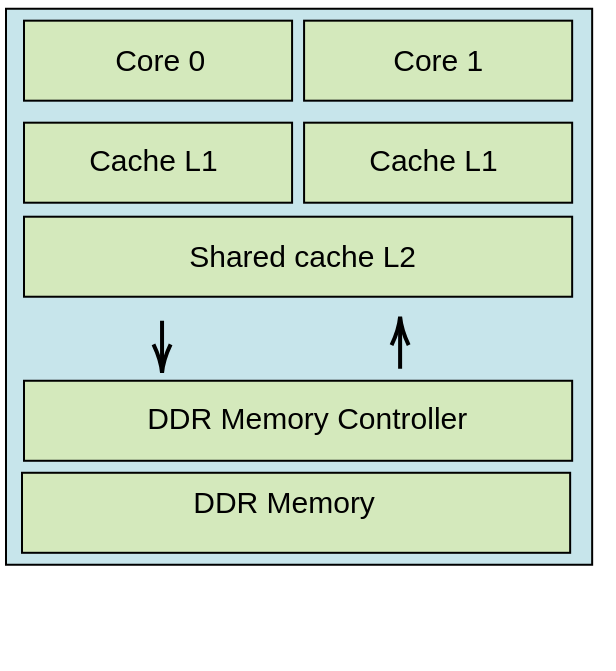

In [83]:
from IPython.display import Image
Image(filename='illustrations/simulator_new.png',width=250) 

## Parameter space 
The simulator takes as input pairs of simplified assembly codes of the shape:
{cycle:(type,address)}
There are only two types *read* and *write*, as memory instructions hire the memory components that are the main sources of interference.
Ex: One can execute (p0,p1) with p0 = p1 = {23:(read,5),32:(read,8),64:(write,5)}. 
## Behavior space explored by IMGEP
Phenomena quantified by performance counters allow for the description of conflicts occurring in shared resources and thus are directly related to interference. However, information is agregated and very limited. We decide to take advantage of the fact that one can access to many information during an execution.
Because interference arises following micro-architectural behavior conflicts, *features* one target are events related to the main types of interference.

| **Feature**                    | **Category** | **Description**                                                             |
|------------------------------|--------------|-----------------------------------------------------------------------------|
| Cache interference | L2 Cache     | Cross-core eviction tracking|
| DDR bank conflicts        | DDR          | When requests are delayed due to bank conflicts |
| DDR scheduler interference    | DDR Controller        |  Tracks when requests are delayed due to higher priority requests  |
| BUS contention  | BUS          | When requests are delayed due to bus bandwidth limitations |

Our features are determined using the following information. Thys, all `events` do not correspond to vectors of the same dimension.
| **Feature**        | **components**                                                                                                                       |
|--------------------|--------------------------------------------------------------------------------------------------------------------------------------|
| **DDR**            | 'row','bank','addr','req_type','scheduled_delay','core_id'                                                                           |
| **DDR scheduler**  | 'bank','addr','req_type','scheduled_delay','core_id', 'core_attacker','type_attacker','addr_attacker','bank_attacker','row_attacker' |
| **L2 cache**       | 'set_idx','evicted_core_id','evicted_instr_id','evicted_addr','causing_core_id','causing_addr'                                       |
| **BUS contention** | 'nb_competing_requests'                                                                                             

## IMGEP

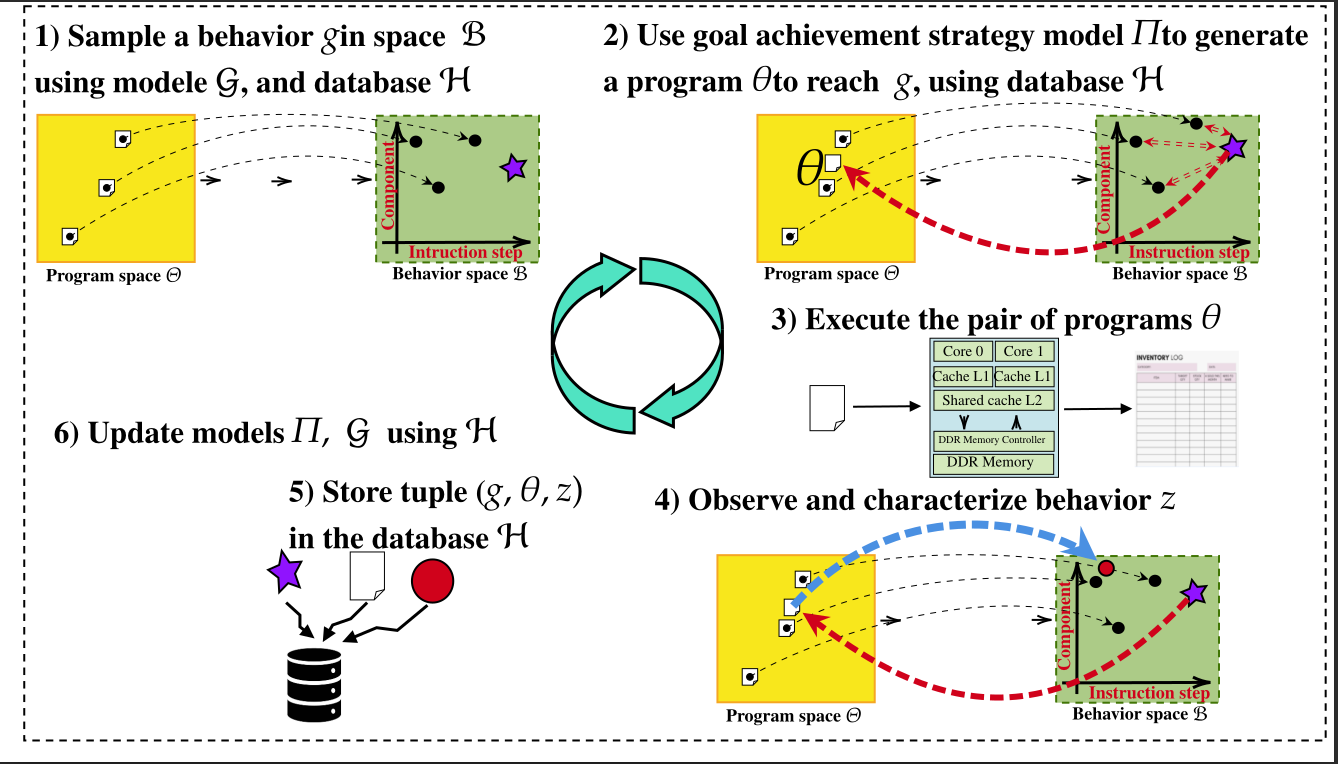

In [84]:
from IPython.display import Image
Image(filename='illustrations/illustration_method.png',width=600) 

## Load exploration results

In [85]:
import pickle
import numpy  as np
from exploration.load_file import load
from diversity.diversty import Diversity
import matplotlib.pyplot as plt
from sklearn.cluster import HDBSCAN

In [114]:
#Load data
folder = "results"
N = 3000
k=1
name_imgep = f'{folder}/imgep_detailled_if_N_{N}_k_{k}'
name_random = f'{folder}/random_detailled_if_N_{N}'
content_imgep = load(name_imgep)
content_random = load(name_random)

results/imgep_detailled_if_N_3000_k_1_15.pkl
results/random_detailled_if_N_3000_15.pkl


## Let's count the number of events for both a imgep and a random exploration

In [115]:
nb_events = {}
for j,content in enumerate([content_random,content_imgep]):
    print(['random','imgep'][j])
    for type_if in content_imgep['memory_observation']:
        keys = list(content['memory_observation'][type_if].keys())
        nb_events[type_if] = (len(content_imgep['memory_observation'][type_if][keys[0]]),len(content_random['memory_observation'][type_if][keys[0]]))

random
imgep


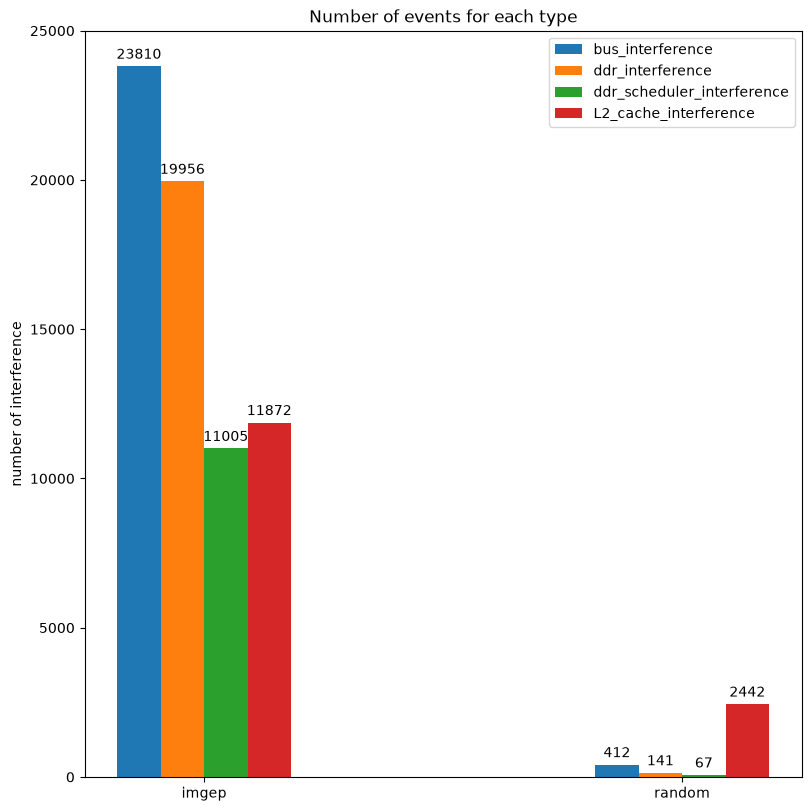

In [116]:
fig, ax = plt.subplots(layout='constrained',figsize=(8,8))

res = ax.grouped_bar(nb_events, tick_labels=['imgep','random'], group_spacing=7)
for container in res.bar_containers:
    ax.bar_label(container, padding=3)

# Add some text for labels, title, etc.
ax.set_ylabel('number of interference')
ax.set_title('Number of events for each type')
ax.legend(loc='upper right', ncols=1)
#ax.set_ylim(0, 250)

plt.show()

## Number of distinct interferences for each type

In [117]:
import numpy as np
import pandas as pd
from utils.history import History

history = History()
history._j = N
distinct_if_counts = {'random':[],'imgep':[]}
names = ['random','imgep']
for j,content in enumerate([content_random,content_imgep]):
    history.memory_observation = content['memory_observation']
    distinct_if_counts[names[j]] = {type_if:np.unique(history.as_tab(type_if)[:-1],axis=1).shape[1] for type_if in content['memory_observation']}

In [118]:
merge_distinct_counts = {}
history1 = History()
history1._j = N
history2 = History()
history2._j = N
history1.memory_observation = content_imgep['memory_observation']
history2.memory_observation = content_random['memory_observation']
for type_if in content_imgep['memory_observation'].keys():
    merge_distinct_counts[type_if] = (np.unique(history1.as_tab(type_if)[:-1],axis=1).shape[1],
                                          np.unique(history2.as_tab(type_if)[:-1],axis=1).shape[1])
    

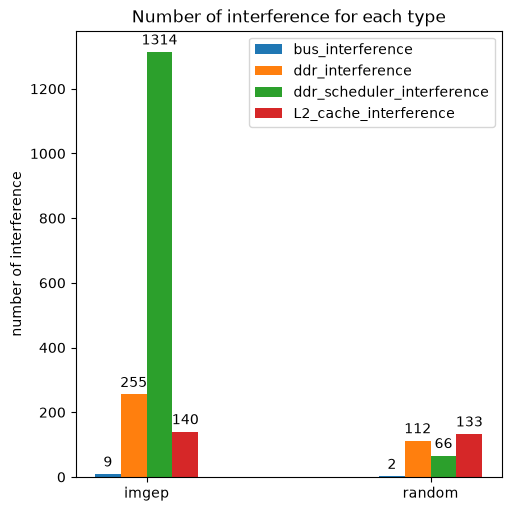

In [119]:
fig, ax = plt.subplots(layout='constrained',figsize=(5,5))

res = ax.grouped_bar(merge_distinct_counts, tick_labels=['imgep','random'], group_spacing=7)
for container in res.bar_containers:
    ax.bar_label(container, padding=3)

# Add some text for labels, title, etc.
ax.set_ylabel('number of interference')
ax.set_title('Number of interference for each type')
ax.legend(loc='upper right', ncols=1)
#ax.set_ylim(0, 250)

plt.show()

# Diffenrent types of behaviors

In [120]:
for if_type in history1.memory_observation:
    print(if_type,history1.memory_observation[if_type].keys())

bus_interference dict_keys(['competing_requests', 'idx'])
ddr_interference dict_keys(['row', 'bank', 'addr', 'req_type', 'scheduled_delay', 'core_id', 'idx'])
ddr_scheduler_interference dict_keys(['bank', 'addr', 'req_type', 'scheduled_delay', 'core_id', 'core_attacker', 'type_attacker', 'addr_attacker', 'bank_attacker', 'row_attacker', 'idx'])
L2_cache_interference dict_keys(['set_idx', 'tag', 'evicted_core_id', 'evicted_instr_id', 'evicted_addr', 'causing_core_id', 'causing_addr', 'idx'])


In [121]:
history1.as_tab('ddr_interference')[3,:]

array([1, 1, 1, ..., 1, 1, 1], shape=(19956,))

In [122]:
def select_idx(sub_list_types,list_types,content):
    '''
    selects programs that exhibit all of interference types from list_types
    '''
    selection = []
    for j in range(N):
        s = 0
        sn = 0
        for if_type in list_types:
            if j in content['memory_observation'][if_type]['idx']:
                if if_type in sub_list_types:
                    s+=1
                else:
                    sn+=1
        if s==len(sub_list_types) and sn==0:
            selection.append(j)
    return len(selection)

In [123]:
list_types = list(content_imgep['memory_observation'].keys())

In [124]:
from itertools import combinations

def get_all_subsets(input_list):
    subsets = []
    for r in range(len(input_list) + 1):
        # combinations() returns tuples, so we convert them to lists
        for combo in combinations(input_list, r):
            subsets.append(list(combo))
    return subsets

# Example usage:
my_list = [1, 2, 3]
power_set = get_all_subsets(list_types)
# Output: [[], [1], [2], [3], [1, 2], [1, 3], [2, 3], [1, 2, 3]]

In [125]:
behavior_counts = {}
for j,subset in enumerate(power_set):
    behavior_counts[j] = (select_idx(subset,list_types,content_imgep),select_idx(subset,list_types,content_random))

In [126]:
power_set[15]

['bus_interference',
 'ddr_interference',
 'ddr_scheduler_interference',
 'L2_cache_interference']

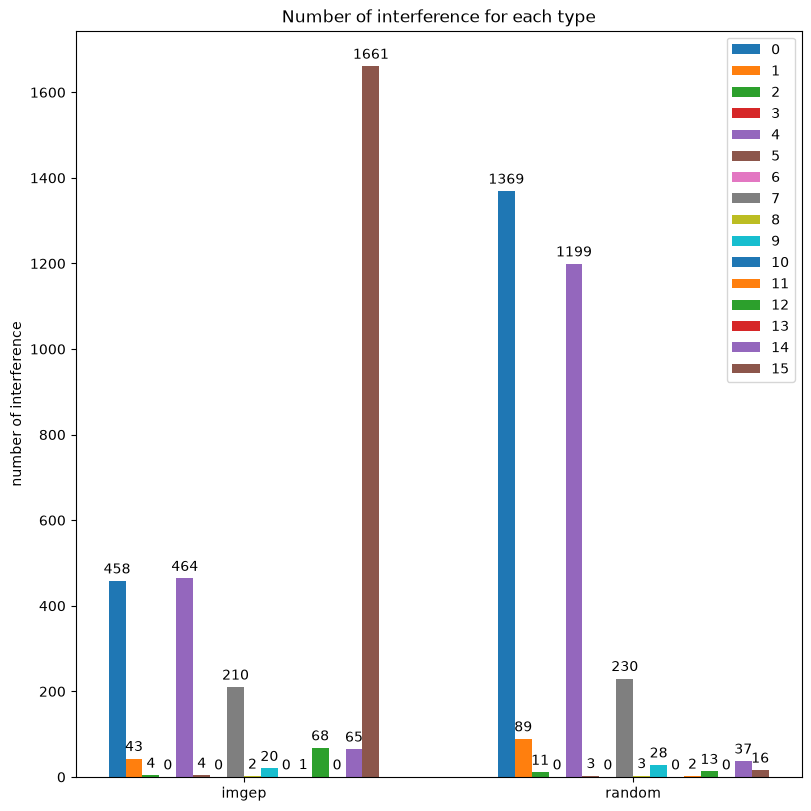

In [127]:
fig, ax = plt.subplots(layout='constrained',figsize=(8,8))

res = ax.grouped_bar(behavior_counts, tick_labels=['imgep','random'], group_spacing=7)
for container in res.bar_containers:
    ax.bar_label(container, padding=3)

# Add some text for labels, title, etc.
ax.set_ylabel('number of interference')
ax.set_title('Number of interference for each type')
ax.legend(loc='upper right', ncols=1)
#ax.set_ylim(0, 250)

plt.show()